# Online Retail Dataset - Data Cleaning & EDA


## Task 1 Dataset Understanding

The Online Retail dataset contains transactional records from a UK-based online retailer, covering purchases made between 01/12/2010 and 09/12/2011.

**Rows** 541909

**Columns** 8

**Numerical features:** Quantity, UnitPrice, CustomerID

**Categorical features:** InvoiceNo, StockCode, Description, InvoiceDate, Country

**Possible unique identifiers:** Initial inspection suggested InvoiceNo could serve as a primary key , butfurther investigation (see Task 2) showed this was not the case.

The dataset represents individual items withincustomer orders - each row is one product purchased as part of a larger invoice/order.


In [2]:
import pandas as pd
df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")
df.head()
import os
os.makedirs("visuals", exist_ok=True)

In [3]:
print(df.shape)

(541909, 8)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
df['InvoiceNo'].nunique()

25900

## Task 2 Data Cleaning

### Missing Values
- **Description**: 1,454 missing values. Filled using a lookup of matching StockCode 
  descriptions from other rows. 112 rows had no available description anywhere in 
  the dataset and were filled with "Unknown".
- **CustomerID**: 135,037 missing values (~25% of rows). Not dropped or imputed, 
  since a fabricated ID would corrupt customer-level analysis. Instead, these 
  rows are excluded only when performing customer-specific analysis 
  (via `df.dropna(subset=['CustomerID'])`), while remaining available for all 
  other analysis.

### Duplicate Records
- 5,268 fully duplicated rows identified via `df.duplicated()` and removed.
- Investigated InvoiceNo + StockCode as a possible natural primary key. After 
  removing exact duplicates, 5,416 rows still shared the same InvoiceNo and 
  StockCode — these were legitimate repeat line entries (same product added 
  more than once to an order at different quantities), not errors.
- Since no natural column combination reliably identifies each row, a 
  surrogate key was created using `df.reset_index()`.

### Invalid Values / Outliers
- **Negative Quantity**: All rows had InvoiceNo prefixed with "C", confirming 
  they represent order cancellations/returns, not data errors. Kept in the 
  dataset and flagged as returns for analysis purposes.
- **Negative UnitPrice**: Found only in 2 rows with StockCode "B" ("Adjust bad 
  debt"), an accounting adjustment rather than a product sale.
- **Non-product StockCodes**: Identified several administrative codes not 
  representing real products — POST, D, C2, DOT, M, m, S, PADS, B, CRUK 
  (postage, discounts, carriage, manual entries, samples, bad debt, and 
  charity donations). These were excluded from a separate `df_products` 
  dataframe used for all product/revenue-level analysis, while remaining in 
  the main `df` for completeness.

### Standardization
- Converted `InvoiceDate` from object/string to proper datetime format.
- Stripped leading/trailing whitespace from `Description`.
- Standardized the "Unspecified" value in `Country` (442 rows) to NaN, 
  treating it consistently as missing data.
- Column names were already clean and consistent - no changes needed.


| Issue Found | Action Taken |
|---|---|
| Missing Description (1,454) | Filled via StockCode lookup; 112 unresolvable filled as "Unknown" |
| Missing CustomerID (135,037) | Left as-is; excluded only for customer-specific analysis |
| Exact duplicate rows (5,268) | Removed |
| No natural primary key | Surrogate key created via reset index |
| Negative Quantity (returns) | Kept, flagged as returns |
| Negative UnitPrice ("bad debt") | Kept in `df`, excluded from `df_products` |
| Non-product StockCodes | Excluded from `df_products` for product/revenue analysis |
| InvoiceDate stored as text | Converted to datetime |
| Inconsistent Description whitespace | Stripped |
| "Unspecified" Country values (442) | Standardized to NaN |


In [7]:
df[df['InvoiceNo'] == df['InvoiceNo'].iloc[0]]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom


In [8]:
df.duplicated(subset=['InvoiceNo', 'StockCode']).sum()

np.int64(10684)

In [9]:
dupes= df[df.duplicated(subset=['InvoiceNo', 'StockCode'], keep=False)]
dupes.sort_values(['InvoiceNo', 'StockCode']).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
113,536381,71270,PHOTO CLIP LINE,1,12/1/2010 9:41,1.25,15311.0,United Kingdom
125,536381,71270,PHOTO CLIP LINE,3,12/1/2010 9:41,1.25,15311.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom


In [10]:
df.duplicated().sum()

np.int64(5268)

In [11]:
df= df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [12]:
df.duplicated(subset=['InvoiceNo', 'StockCode']).sum()

np.int64(5416)

In [13]:
remaining = df[df.duplicated(subset=['InvoiceNo', 'StockCode'], keep=False)]
remaining.sort_values(['InvoiceNo', 'StockCode']).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
113,536381,71270,PHOTO CLIP LINE,1,12/1/2010 9:41,1.25,15311.0,United Kingdom
125,536381,71270,PHOTO CLIP LINE,3,12/1/2010 9:41,1.25,15311.0,United Kingdom
491,536409,85116,BLACK CANDELABRA T-LIGHT HOLDER,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
502,536409,85116,BLACK CANDELABRA T-LIGHT HOLDER,5,12/1/2010 11:45,2.10,17908.0,United Kingdom
483,536409,90199C,5 STRAND GLASS NECKLACE CRYSTAL,3,12/1/2010 11:45,6.35,17908.0,United Kingdom
498,536409,90199C,5 STRAND GLASS NECKLACE CRYSTAL,1,12/1/2010 11:45,6.35,17908.0,United Kingdom
525,536409,90199C,5 STRAND GLASS NECKLACE CRYSTAL,2,12/1/2010 11:45,6.35,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,12/1/2010 11:49,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom
561,536412,21738,COSY SLIPPER SHOES SMALL RED,1,12/1/2010 11:49,2.95,17920.0,United Kingdom


In [14]:
 df= df.reset_index(drop=True)
df['RowID'] = df.index


In [15]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
RowID               0
dtype: int64

In [16]:
df['Description'].isnull().sum()  # before
description_map = df.dropna(subset=['Description']).groupby('StockCode')['Description'].first()
df['Description'] = df['Description'].fillna(df['StockCode'].map(description_map))
df['Description'].isnull().sum()  # after

np.int64(112)

In [17]:
df_with_customers = df.dropna(subset=['CustomerID'])

In [18]:
df[df['Quantity'] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,RowID
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom,141
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom,154
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom,235
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,236
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,237
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,238
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,12/1/2010 10:24,3.45,17548.0,United Kingdom,239
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom,240
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,12/1/2010 10:24,1.65,17548.0,United Kingdom,241
916,C536506,22960,JAM MAKING SET WITH JARS,-6,12/1/2010 12:38,4.25,17897.0,United Kingdom,916


In [19]:
df[df['UnitPrice'] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,RowID
297646,A563186,B,Adjust bad debt,1,8/12/2011 14:51,-11062.06,NaN,United Kingdom,297646
297647,A563187,B,Adjust bad debt,1,8/12/2011 14:52,-11062.06,NaN,United Kingdom,297647


In [20]:
df_products = df[df['StockCode'] != 'B']

In [21]:
df['StockCode'].value_counts().tail(20)

StockCode
21310     1
84596l    1
21134     1
20957     1
85226A    1
84963A    1
35600A    1
84206B    1
23609     1
85179a    1
23617     1
90214U    1
47591b    1
85049c    1
72802c    1
23652     1
23602     1
23664     1
23449     1
85034b    1
Name: count, dtype: int64

In [22]:
df[df['StockCode'].str.len() <= 4]['StockCode'].unique()

array(['POST', 'D', 'C2', 'DOT', 'M', 'S', 'm', 'PADS', 'B', 'CRUK'],
      dtype=object)

In [23]:
non_product_codes = ['POST', 'D', 'C2', 'DOT', 'M', 'm', 'S', 'PADS', 'B', 'CRUK']
df_products = df[~df['StockCode'].isin(non_product_codes)]

In [24]:
df_products.shape

(533802, 9)

In [25]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
RowID            int64
dtype: object

In [26]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [27]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
RowID                   int64
dtype: object

In [28]:
df['Description'].str.strip().equals(df['Description'])

False

In [29]:
df['Description'] = df['Description'].str.strip()

In [30]:
df['Description'].str.strip().equals(df['Description'])

True

In [31]:
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [32]:
df['Country'].value_counts()

Country
United Kingdom          490300
Germany                   9480
France                    8541
EIRE                      8184
Spain                     2528
Netherlands               2371
Belgium                   2069
Switzerland               1994
Portugal                  1510
Australia                 1258
Norway                    1086
Italy                      803
Channel Islands            757
Finland                    695
Cyprus                     611
Sweden                     461
Unspecified                442
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     294
USA                        291
Hong Kong                  284
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


In [33]:
df['Country'] = df['Country'].replace('Unspecified', pd.NA)

In [34]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'RowID'],
      dtype='object')

In [35]:
df.to_csv("retail_cleaned.csv", index=False)

## Task 3: Exploratory Data Analysis (EDA)

### Summary Statistics
Generated summary statistics (mean, median, min, max, standard deviation) for 
Quantity and UnitPrice using `df_products.describe()`. Quantity ranges from 
-80,995 to 80,995 (reflecting cancellations at the extreme), with a mean of 
~9.65 units per line item. UnitPrice ranges from 0 to 17,836.46, with a mean 
of ~£3.76.

### Data Patterns Explored

**1. Top-Selling Products (by Quantity)**
Filtered to actual sales only (`Quantity > 0`, excluding returns/cancellations). 
"PAPER CRAFT, LITTLE BIRDIE" leads with 80,995 units sold, followed by 
"MEDIUM CERAMIC TOP STORAGE JAR" (78,033) and "WORLD WAR 2 GLIDERS ASSTD 
DESIGNS" (54,951).

**2. Revenue by Country**
The United Kingdom dominates revenue at ~£8.74M, unsurprising given this is a 
UK-based retailer. The Netherlands (£283,889) and EIRE (£270,851) are distant 
second and third, with revenue dropping off sharply after the top 5 countries.

**3. Most Purchased Products (by Revenue)**
"REGENCY CAKESTAND 3 TIER" generates the most revenue (£174,157), despite not 
appearing in the top-selling-by-quantity list - suggesting it sells in lower 
volumes but at a higher price point per unit than the volume leaders.

**4. Monthly Sales Trend**
Revenue trends upward through the year, peaking in November 2011 (£1,452,146), 
likely tied to holiday season buying. December 2011 shows a sharp apparent 
drop (£614,514), but this reflects incomplete data - the dataset cuts off on 
9 December 2011 - rather than a genuine seasonal decline.

**5. Top Customers by Revenue**
Customer 14646 is the highest-value customer, generating £279,138 - 
significantly ahead of the next highest (£259,657). Across all customers, the 
average is 4.25 distinct orders each (median: 2), with a maximum of 206 orders 
from a single customer, indicating a small base of highly repeat purchasers 
alongside many one-time or low-frequency buyers.


In [36]:
df_products[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,533802.000000,533802.000000
mean,9.652433,3.758458
std,219.657509,69.003019
min,-80995.000000,0.000000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,17836.460000


In [37]:
df_sales = df_products[df_products['Quantity'] > 0].copy()
df_sales.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48375
WHITE HANGING HEART T-LIGHT HOLDER    37876
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    31555
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [38]:
df_sales['Revenue'] = df_sales['Quantity'] * df_sales['UnitPrice']
df_sales.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    8739055.571
Netherlands        283889.340
EIRE               270850.860
Germany            205381.150
France             184493.000
Australia          138103.810
Spain               55706.560
Switzerland         53065.600
Japan               37416.370
Belgium             36927.340
Name: Revenue, dtype: float64

In [39]:
df_sales.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

Description
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
RABBIT NIGHT LIGHT                     66870.03
PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
ASSORTED COLOUR BIRD ORNAMENT          58927.62
CHILLI LIGHTS                          54096.36
Name: Revenue, dtype: float64

In [40]:
df_sales['InvoiceDate'] = pd.to_datetime(df_sales['InvoiceDate'])
df_sales['InvoiceMonth'] = df_sales['InvoiceDate'].dt.to_period('M')
df_sales.groupby('InvoiceMonth')['Revenue'].sum()

InvoiceMonth
2010-12     789271.280
2011-01     670454.460
2011-02     507866.540
2011-03     690061.600
2011-04     515484.660
2011-05     740051.330
2011-06     737683.990
2011-07     688252.670
2011-08     724308.160
2011-09    1028375.381
2011-10    1103360.920
2011-11    1452145.980
2011-12     614514.250
Freq: M, Name: Revenue, dtype: float64

In [41]:
df_sales['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [42]:
df_sales.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

CustomerID
14646.0    279138.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    136161.83
12415.0    124564.53
14156.0    116560.08
17511.0     91062.38
12346.0     77183.60
16029.0     72708.09
Name: Revenue, dtype: float64

In [43]:
df_sales.groupby('CustomerID')['InvoiceNo'].nunique().describe()

count    4336.000000
mean        4.247232
std         7.639830
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       206.000000
Name: InvoiceNo, dtype: float64

## Task 4: Data Visualization

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

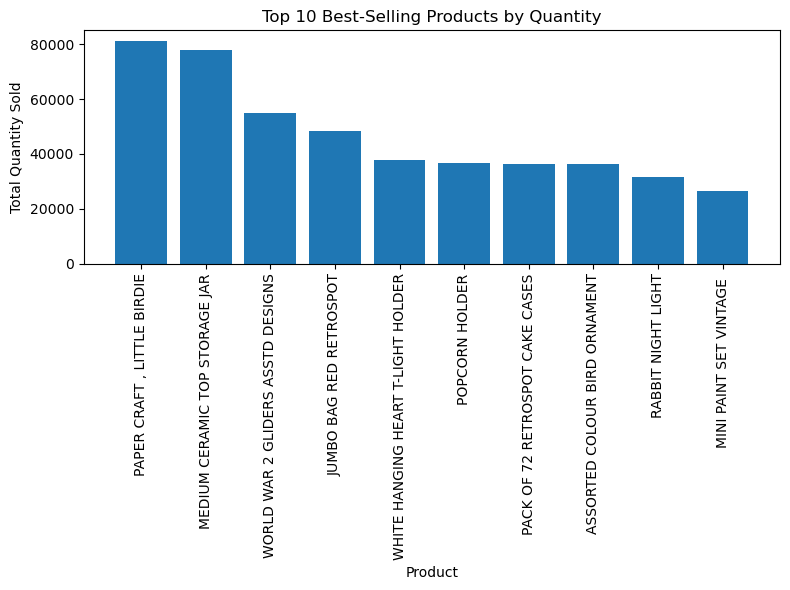

In [45]:
top_products = df_sales.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
plt.bar(top_products.index, top_products.values)
plt.title('Top 10 Best-Selling Products by Quantity')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("visuals/top_products_bar.png")
plt.show()

**Chart 1: Top 10 Best-Selling Products by Quantity**

"PAPER CRAFT, LITTLE BIRDIE" is the best-selling product by units sold, 
followed by "MEDIUM CERAMIC TOP STORAGE JAR" and "WORLD WAR 2 GLIDERS ASSTD DESIGNS."


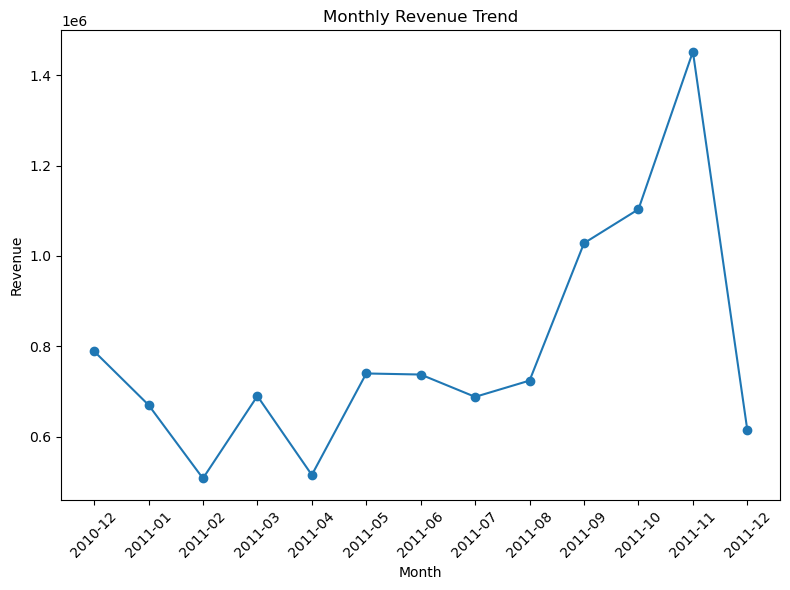

In [46]:
monthly_revenue = df_sales.groupby('InvoiceMonth')['Revenue'].sum()
monthly_revenue.index = monthly_revenue.index.astype(str)

plt.figure(figsize=(8,6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("visuals/monthly_revenue_line.png")
plt.show()


**Chart 2: Monthly Revenue Trend**

Revenue generally trends upward through the year, peaking in November 2011 
(~£1.45M), likely driven by holiday season buying. The apparent drop in 
December 2011 reflects incomplete data (dataset ends 9 December 2011) rather 
than an actual seasonal decline.



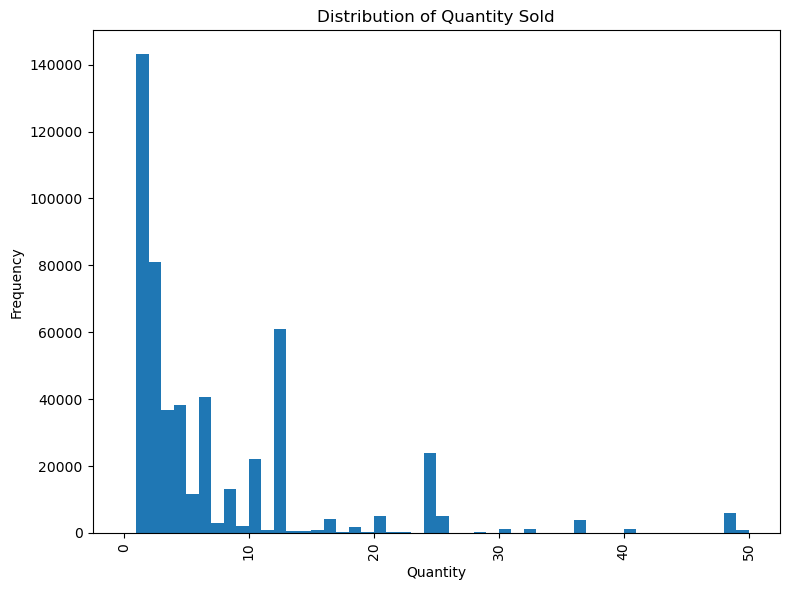

In [47]:
plt.figure(figsize=(8,6))
plt.hist(df_sales['Quantity'], bins=50, range=(0, 50))
plt.title('Distribution of Quantity Sold')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("visuals/quantity_histogram.png")
plt.show()

**Chart 3: Distribution of Quantity Sold (0-50 units)**
                                          
The vast majority of line items involve small quantities, with a sharp peak 
around 1-2 units. Noticeable secondary spikes appear around common round 
numbers like 10, 12, and 24, reflecting typical bulk/gift packaging sizes. 
The chart is zoomed to 0-50 since a small number of extreme outliers (up to 
~81,000 units in a single order) would otherwise compress the entire 
distribution into an unreadable single bar.



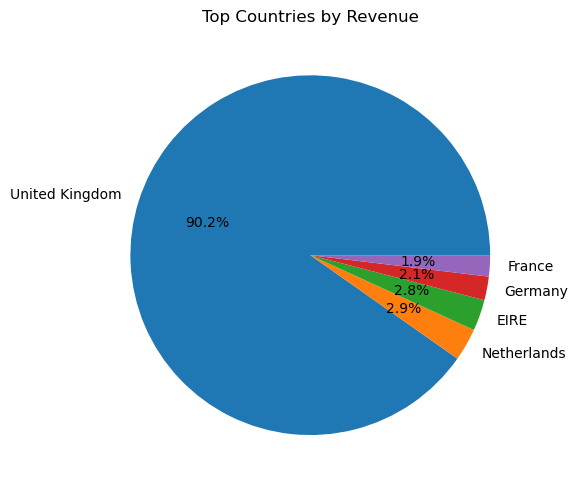

In [48]:
top_countries = df_sales.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(7,5))
plt.pie(top_countries.values, labels=top_countries.index,  autopct='%1.1f%%')
plt.title('Top Countries by Revenue')
plt.tight_layout()
plt.savefig("visuals/countries_pie.png")
plt.show()

**Chart 4: Top Countries by Revenue Share**

The United Kingdom accounts for 90.2% of total revenue, reflecting the 
retailer's UK-based customer base. The remaining top countries (Netherlands, 
EIRE, Germany, France) each contribute under 3%, showing how concentrated the 
business is domestically.


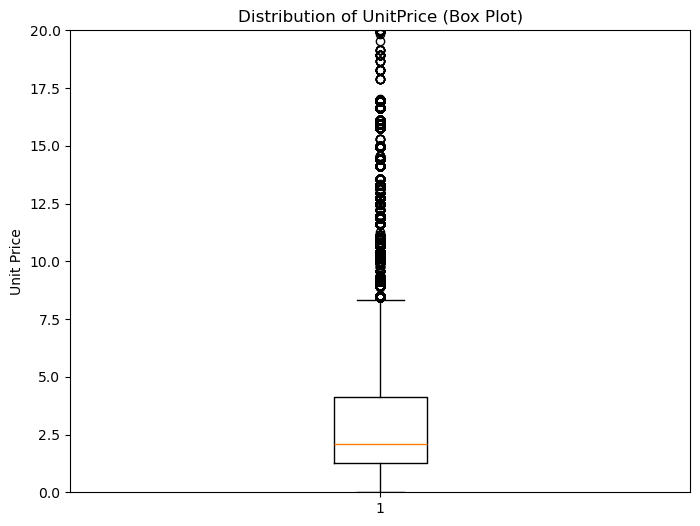

In [49]:
plt.figure(figsize=(8,6))
plt.boxplot(df_sales['UnitPrice'])
plt.title('Distribution of UnitPrice (Box Plot)')
plt.ylabel('Unit Price')
plt.ylim(0, 20)
plt.savefig("visuals/unitprice_boxplot.png")
plt.show()

**Chart 5: Distribution of UnitPrice (Box Plot, capped at £20)**
                                      
The median unit price sits around £2, with the middle 50% of items priced 
between roughly £1.25 and £4.13. A large number of values above ~£8 are 
flagged as statistical outliers, though many represent legitimate 
higher-priced products rather than data errors; reflecting the wide price 
range typical of a diverse product catalog. The view is capped at £20 to 
keep the box readable, since a small number of extreme outliers (up to 
£17,836) would otherwise compress it into an unreadable line.


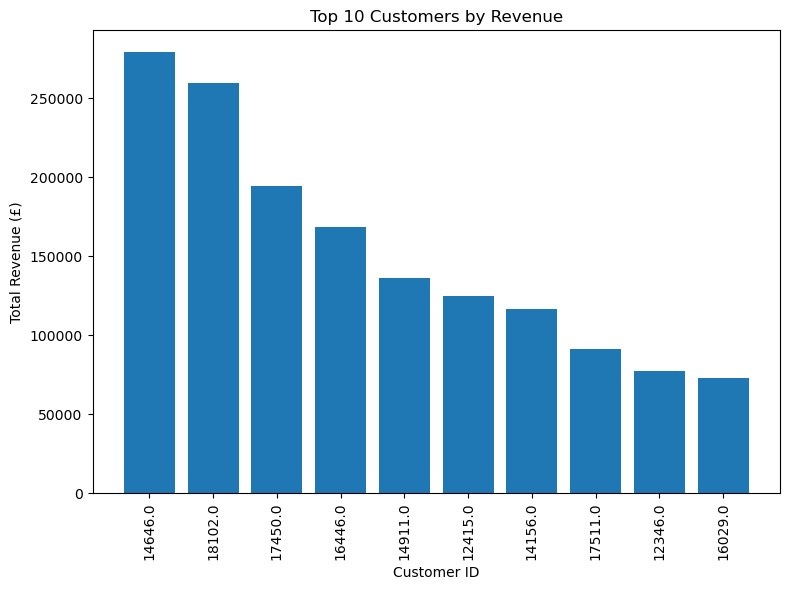

In [50]:
top_customers = df_sales.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
plt.bar(top_customers.index.astype(str), top_customers.values)
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("visuals/top_customers_bar.png")
plt.show()

**Chart 6: Top Customers by Revenue**

Revenue is concentrated among a small number of high-value customers.
The top customer alone generated £279,138, while the average customer placed 
just 4.25 orders (median: 2).


## Task 5: Insights

**1. The UK dominates the business almost entirely.**
90.2% of total revenue comes from the United Kingdom, with the next closest 
country (Netherlands) contributing under 3%. This confirms the retailer 
operates primarily as a domestic UK business rather than a genuinely 
international one (see Chart 4: Top Countries by Revenue Share).

**2. Best-sellers by volume aren't the same as top revenue earners.**
"PAPER CRAFT, LITTLE BIRDIE" leads in units sold, but "REGENCY CAKESTAND 
3 TIER" generates the most revenue overall despite not appearing in the 
top-selling-by-quantity list. This suggests some products sell in high 
volumes at low margins, while others sell less frequently but at a higher 
price point (see Chart 1 and Task 3 point 3).

**3. Most purchases are small, everyday-sized orders.**
The distribution of quantity sold is heavily skewed toward small amounts, 
with a sharp peak around 1-2 units and secondary spikes at common bulk sizes 
like 10, 12, and 24 — likely reflecting typical retail packaging (see Chart 3).

**4. Sales build steadily toward a November peak, consistent with holiday shopping.**
Monthly revenue rises through the year, peaking in November 2011 at 
£1,452,146. The apparent sharp drop in December is not a real decline — the 
dataset simply ends on 9 December 2011 (see Chart 2).

**5. Revenue is concentrated among a small number of high-value customers.**
The top customer alone generated £279,138, while the average customer placed 
just 4.25 orders (median: 2). This points to a small base of loyal, 
high-spending customers alongside a much larger group of one-time or 
infrequent buyers; a useful distinction for any future customer retention 
strategy. (see Chart 6)
